In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt

In [20]:
# ---------------------------
# 0. Load data (already engineered)
# ---------------------------
df = pd.read_csv("../data/patient_features_with_encounter_cluster.csv")

df['encounter_start_dt'] = pd.to_datetime(df['encounter_start_dt'], errors='coerce')
df['encounter_end_dt']   = pd.to_datetime(df['encounter_end_dt'],   errors='coerce')

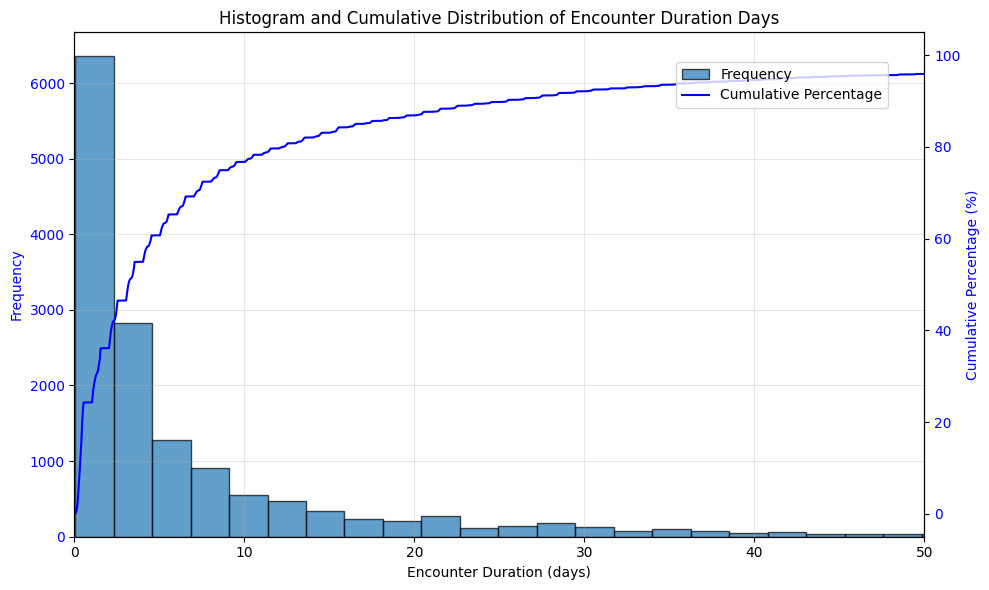

In [21]:
data = df['encounter_duration_days'].dropna()

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.hist(data, bins=100, edgecolor='black', alpha=0.7, label='Frequency')
ax1.set_xlabel('Encounter Duration (days)')
ax1.set_ylabel('Frequency', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(alpha=0.3)
ax1.set_xlim(0, 50)

ax2 = ax1.twinx()
data_sorted = data.sort_values()
y = np.arange(1, len(data_sorted) + 1) / len(data_sorted) * 100 
ax2.plot(data_sorted, y, color='blue', label='Cumulative Percentage')
ax2.set_ylabel('Cumulative Percentage (%)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Histogram and Cumulative Distribution of Encounter Duration Days')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.tight_layout()
plt.show()

In [ ]:
# Use icd_prefix3_unique_str, encode and binarize and use for training
df["icd_prefix3_unique_str"] = df.icd_prefix3_unique_str.fillna("").apply(
    lambda x: [str(code).strip() for code in x.split("|")] if x else []
)

mlb = MultiLabelBinarizer(sparse_output=True)
proc_code_mlb = mlb.fit_transform(df["icd_prefix3_unique_str"])

codes_df = pd.DataFrame.sparse.from_spmatrix(
    proc_code_mlb,
    columns=mlb.classes_,
    index = df.index
)

mlb_columns = [i for i in list(mlb.classes_) if i not in df.columns.to_list()]
# additional_columns = list(tfidf.get_feature_names_out()) + list(mlb.classes_)
additional_columns = list(set(mlb_columns))
all_df = pd.concat([df, codes_df[mlb_columns]], axis=1)


In [ ]:
# Use proc codes and description, encode and binarize and use for training
all_columns = ['patient_id', 'encounter_id', 'icd_prefix3_unique_str', 'n_icd_prefix3',
       'encounter_start_dt', 'encounter_end_dt', 'encounter_duration_days',
       'encounter_setting', 'encounter_medical_service',
       'adt_event_types_seq_str', 'adt_event_times_seq_str',
       'PATIENT_BIRTH_YEAR', 'PATIENT_SEX', 'PATIENT_RACE_ETHNICITY',
       'DECEASED_FLAG', 'age', 'med_order_nunique', 'proc_codes_seq_str',
       'proc_descs_seq_str', 'proc_times_seq_str', 'proc_count',
       'past_num_encounters', 'past_total_procedures', 'past_total_icd_codes',
       'past_total_encounter_days', 'encounter_cluster']
df["proc_code_seq_list"] = df.proc_codes_seq_str.fillna("").apply(
    lambda x: [str(code).strip() for code in x.split("|")] if x else []
)

mlb = MultiLabelBinarizer(sparse_output=True)
proc_code_mlb = mlb.fit_transform(df["proc_code_seq_list"])

codes_df = pd.DataFrame.sparse.from_spmatrix(
    proc_code_mlb,
    columns=mlb.classes_,
    index = df.index
)

tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df = 5,
    max_features = 2000,
    stop_words="english"
)
proc_desc_tfidf = tfidf.fit_transform(df["proc_descs_seq_str"].fillna("").tolist())
desc_df = pd.DataFrame.sparse.from_spmatrix(
    proc_desc_tfidf,
    columns=tfidf.get_feature_names_out(),
    index = df.index
)

tfidf_columns = [i for i in list(tfidf.get_feature_names_out()) if i not in df.columns.to_list()]
mlb_columns = [i for i in list(mlb.classes_) if i not in df.columns.to_list()]
# additional_columns = list(tfidf.get_feature_names_out()) + list(mlb.classes_)
additional_columns = list(set(mlb_columns + tfidf_columns))
all_df = pd.concat([df, codes_df[mlb_columns], desc_df[tfidf_columns]], axis=1)


In [56]:
# ---------------------------
# 2. Feature sets
#    Remove encounter_setting; keep encounter_medical_service (categorical).
#    Cluster version adds 'encounter_cluster'.
# ---------------------------

base_features = [
    'age', 'PATIENT_SEX', 'PATIENT_RACE_ETHNICITY',
    'encounter_medical_service', 'n_icd_prefix3',
    'past_num_encounters', 'past_total_procedures',
    'past_total_icd_codes', 'past_total_encounter_days'
    # DO NOT include encounter_setting
]
base_features    = [c for c in base_features if c in df.columns]


def build_preproc(feature_list):
    # separate categorical and numeric
    cat_cols = [c for c in feature_list if df[c].dtype == 'object']
    num_cols = [c for c in feature_list if c not in cat_cols]

    preproc = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
            ('num', 'passthrough', num_cols)
        ],
        remainder='drop'
    )
    return preproc, cat_cols, num_cols

def fit_and_eval_cls(
        feature_list, y_col, 
        label, df_train, df_test,
        use_additional=False
        ):
    use_cols = feature_list.copy()
    preproc, cat_cols, num_cols = build_preproc(use_cols)
    if use_additional:
        use_cols += additional_columns
    clf = LGBMClassifier(
        subsample=0.7,
        reg_lambda=1.0,
        reg_alpha=1.0,
        n_estimators=300,
        min_child_samples=5,
        learning_rate=np.float64(0.01),
        num_leaves=31,
        colsample_bytree=1,
    )
    pipe = Pipeline([
        ('prep', preproc),
        ('lgbm', clf)
    ])
    X_tr, y_tr = df_train[use_cols], df_train[y_col]
    X_te, y_te = df_test[use_cols],  df_test[y_col]

    pipe.fit(X_tr, y_tr)
    proba = pipe.predict_proba(X_te)[:,1]
    pred  = (proba >= 0.5).astype(int)

    auc = roc_auc_score(y_te, proba)
    ap  = average_precision_score(y_te, proba)
    print(f"[{label}] Classifier {y_col}: AUC={auc:.3f}, PR-AUC={ap:.3f}")
    print(classification_report(y_te, pred, digits=3))
    return pipe, proba, {'AUC': auc, 'PR_AUC': ap}
    

In [35]:
# ---------------------------
# 3. Train/Test split with GroupKFold (by patient)
#    We first create a single holdout split to report metrics consistently.
# ---------------------------
# Create groups
groups = df['patient_id'].astype(str)
gkf = GroupKFold(n_splits=5)
all_df = df
train_idx, test_idx = next(gkf.split(all_df, groups=groups))

df_train = all_df.iloc[train_idx].reset_index(drop=True)
df_test = all_df.iloc[test_idx].reset_index(drop=True)

In [46]:
# ---------------------------
# 4. Train & evaluate (Base vs Cluster)
# ---------------------------
print("Data shape:", all_df.shape)

results = []
results_df = pd.DataFrame()
target_days = 'encounter_duration_days'

los_to_predict = 20
for long_stay_threshold in range(1, los_to_predict+1):
    df_train['is_long_stay'] = df_train[target_days] >= long_stay_threshold
    df_test['is_long_stay'] = df_test[target_days] >= long_stay_threshold

    base_cls, base_prob_long, base_cls_metrics = fit_and_eval_cls(
        base_features, 'is_long_stay', "Base", 
        df_train, df_test)
    results_df[f"prob_longer_than_{long_stay_threshold}"] = base_prob_long
    results.append((base_prob_long, base_cls_metrics))


Data shape: (15116, 26)
[LightGBM] [Info] Number of positive: 9143, number of negative: 2949
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027327 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 362
[LightGBM] [Info] Number of data points in the train set: 12092, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.756120 -> initscore=1.131522
[LightGBM] [Info] Start training from score 1.131522
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

c:\Users\david\OneDrive\Desktop\GraiMatter\progress\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[Base] Classifier is_long_stay: AUC=0.952, PR-AUC=0.982
              precision    recall  f1-score   support

       False      0.823     0.895     0.857       721
        True      0.966     0.940     0.953      2303

    accuracy                          0.929      3024
   macro avg      0.894     0.917     0.905      3024
weighted avg      0.932     0.929     0.930      3024

[LightGBM] [Info] Number of positive: 7724, number of negative: 4368
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000870 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 362
[LightGBM] [Info] Number of data points in the train set: 12092, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.638769 -> initscore=0.570027
[LightGBM] [Info] Start training from score 0.570027


c:\Users\david\OneDrive\Desktop\GraiMatter\progress\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[Base] Classifier is_long_stay: AUC=0.905, PR-AUC=0.918
              precision    recall  f1-score   support

       False      0.996     0.742     0.851      1090
        True      0.873     0.998     0.932      1934

    accuracy                          0.906      3024
   macro avg      0.935     0.870     0.891      3024
weighted avg      0.917     0.906     0.902      3024

[LightGBM] [Info] Number of positive: 6464, number of negative: 5628
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000717 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 362
[LightGBM] [Info] Number of data points in the train set: 12092, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.534568 -> initscore=0.138494
[LightGBM] [Info] Start training from score 0.138494


...

c:\Users\david\OneDrive\Desktop\GraiMatter\progress\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[Base] Classifier is_long_stay: AUC=0.826, PR-AUC=0.431
              precision    recall  f1-score   support

       False      0.865     0.986     0.921      2582
        True      0.544     0.097     0.165       442

    accuracy                          0.856      3024
   macro avg      0.704     0.542     0.543      3024
weighted avg      0.818     0.856     0.811      3024

[LightGBM] [Info] Number of positive: 1645, number of negative: 10447
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000688 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 362
[LightGBM] [Info] Number of data points in the train set: 12092, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.136040 -> initscore=-1.848574
[LightGBM] [Info] Start training from score -1.848574


c:\Users\david\OneDrive\Desktop\GraiMatter\progress\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[Base] Classifier is_long_stay: AUC=0.833, PR-AUC=0.435
              precision    recall  f1-score   support

       False      0.868     0.993     0.926      2600
        True      0.638     0.071     0.127       424

    accuracy                          0.864      3024
   macro avg      0.753     0.532     0.527      3024
weighted avg      0.835     0.864     0.814      3024

[LightGBM] [Info] Number of positive: 1573, number of negative: 10519
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000624 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 362
[LightGBM] [Info] Number of data points in the train set: 12092, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.130086 -> initscore=-1.900199
[LightGBM] [Info] Start training from score -1.900199
[Base] Classifier is_long_stay: AUC=0.833, PR-AUC=0.441
     

c:\Users\david\OneDrive\Desktop\GraiMatter\progress\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [47]:
results_df["encounter_start_dt"] = df_test["encounter_start_dt"]
results_df["encounter_medical_service"] = df_test["encounter_medical_service"]
results_df.sort_values("encounter_start_dt", inplace=True)
results_df

,prob_longer_than_1,prob_longer_than_2,prob_longer_than_3,prob_longer_than_4,prob_longer_than_5,prob_longer_than_6,prob_longer_than_7,prob_longer_than_8,prob_longer_than_9,prob_longer_than_10,...,prob_longer_than_13,prob_longer_than_14,prob_longer_than_15,prob_longer_than_16,prob_longer_than_17,prob_longer_than_18,prob_longer_than_19,prob_longer_than_20,encounter_start_dt,encounter_medical_service
1596,0.964981,0.888249,0.821325,0.786902,0.766202,0.715573,0.675167,0.668435,0.617692,0.622318,...,0.545350,0.523899,0.515352,0.494638,0.473772,0.460467,0.442149,0.434178,2022-11-01 00:00:00+00:00,Nursing - medical / surgical
848,0.975381,0.849916,0.651399,0.521238,0.398148,0.320102,0.218332,0.211156,0.181506,0.141883,...,0.089494,0.079822,0.074202,0.055596,0.054537,0.043040,0.037501,0.038615,2022-11-01 00:00:00+00:00,Nursing - medical / surgical
601,0.980238,0.827123,0.665814,0.532191,0.459645,0.381176,0.351144,0.314323,0.298380,0.254986,...,0.209449,0.204207,0.168539,0.162087,0.147746,0.138713,0.132859,0.137718,2022-11-01 00:00:00+00:00,Nursing - medical / surgical
2720,0.975381,0.849916,0.651399,0.521238,0.398148,0.320425,0.231378,0.210348,0.183456,0.147584,...,0.104571,0.090730,0.083525,0.073499,0.065253,0.065620,0.052342,0.047961,2022-11-01 00:00:00+00:00,Nursing - medical / surgical
932,0.964984,0.905892,0.868342,0.837795,0.804294,0.794793,0.754218,0.716786,0.692606,0.671262,...,0.603399,0.571970,0.555693,0.545251,0.509268,0.499496,0.485306,0.459818,2022-11-01 00:00:00+00:00,Nursing - medical / surgical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199,0.980238,0.863960,0.750867,0.586886,0.480047,0.427077,0.369147,0.345152,0.297715,0.264609,...,0.176450,0.184609,0.154767,0.147218,0.132386,0.121855,0.118584,0.115891,2023-02-28 00:00:00+00:00,Nursing - medical / surgical
447,0.964981,0.888249,0.821325,0.786902,0.766202,0.715573,0.675167,0.668435,0.617692,0.622318,...,0.545350,0.523899,0.515352,0.494638,0.473772,0.460467,0.442149,0.434178,2023-02-28 00:00:00+00:00,Nursing - medical / surgical
1442,0.980238,0.827123,0.664462,0.532191,0.459645,0.381176,0.348264,0.314613,0.292836,0.254331,...,0.197606,0.188931,0.159179,0.146042,0.130888,0.130036,0.129802,0.130649,2023-02-28 00:00:00+00:00,Nursing - medical / surgical
308,0.980238,0.872329,0.691231,0.537663,0.474646,0.372618,0.298867,0.280231,0.245449,0.225386,...,0.173881,0.142119,0.143536,0.151022,0.145721,0.150550,0.129222,0.094553,2023-02-28 00:00:00+00:00,Nursing - medical / surgical


In [48]:
prob_cols = [f"prob_longer_than_{i}" for i in range(1,los_to_predict+1)]

workloads = (
    results_df.groupby("encounter_start_dt")[prob_cols]
      .sum()
      .reset_index()
)

dates = pd.date_range(
    start=df["encounter_start_dt"].min().normalize(),
    end=df["encounter_start_dt"].max().normalize() + pd.Timedelta(days=len(prob_cols)),
    freq="D",
    tz="UTC"
)

daily_workload = pd.Series(0.0, index=dates)
for _, row in workloads.iterrows():
    encounter_start_dt = row["encounter_start_dt"].normalize()

    for k, col in enumerate(prob_cols):
        workload_date = encounter_start_dt + pd.Timedelta(days=k)
        daily_workload.loc[workload_date] += row[col]
daily_workload_df = (
    daily_workload
    .rename("expected_workload")
    .reset_index()
    .rename(columns={"index": "date"})
)

daily_workload_df


,date,expected_workload
0,2022-11-01 00:00:00+00:00,18.599990
1,2022-11-02 00:00:00+00:00,27.261106
2,2022-11-03 00:00:00+00:00,56.892896
3,2022-11-04 00:00:00+00:00,64.906437
4,2022-11-05 00:00:00+00:00,77.882315
...,...,...
135,2023-03-16 00:00:00+00:00,11.381756
136,2023-03-17 00:00:00+00:00,8.004441
137,2023-03-18 00:00:00+00:00,5.227926
138,2023-03-19 00:00:00+00:00,2.375761


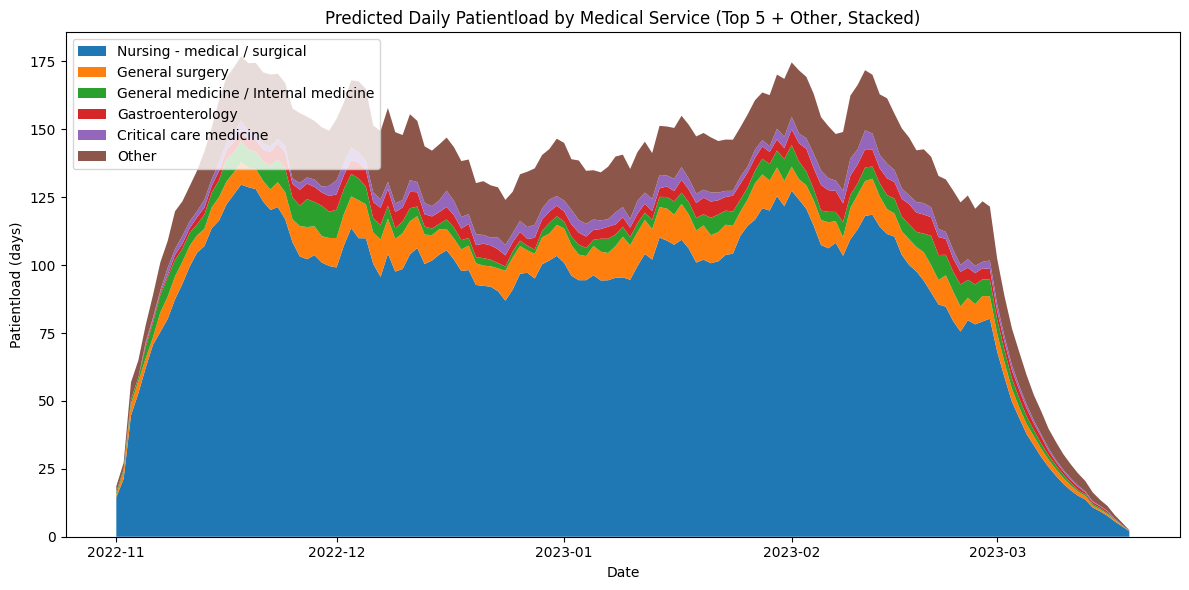

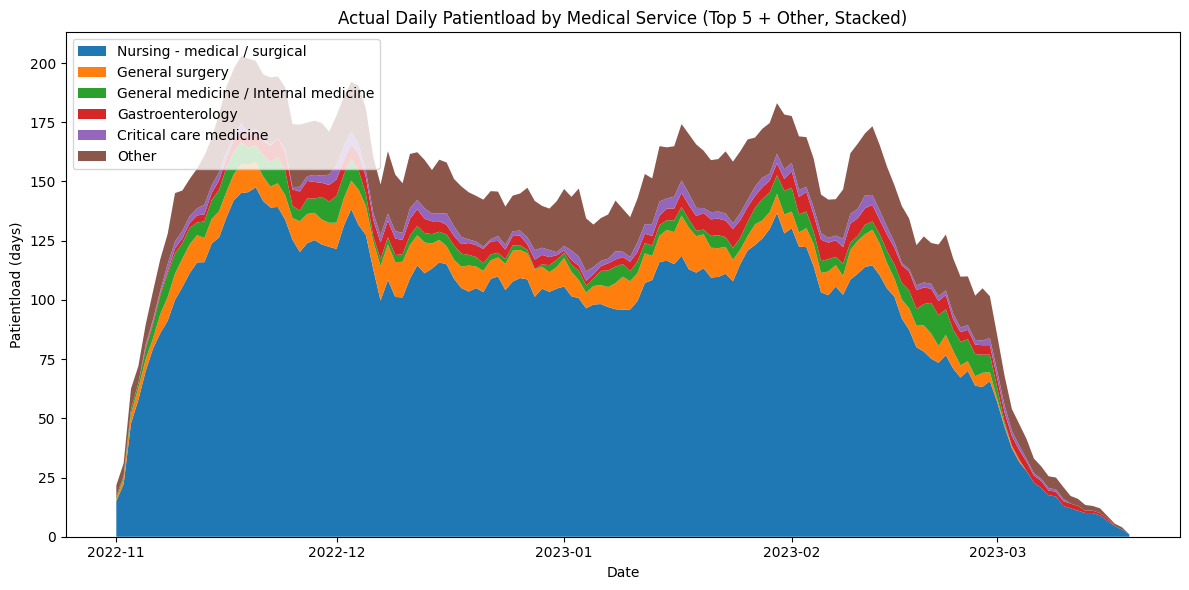

In [49]:
workloads = results_df.groupby(["encounter_start_dt", "encounter_medical_service"])[prob_cols].sum().reset_index()

predicted_contribs = []
for _, row in workloads.iterrows():
    start_dt = row["encounter_start_dt"].normalize()
    service = row["encounter_medical_service"]
    for k, col in enumerate(prob_cols):
        date = start_dt + pd.Timedelta(days=k)
        contrib = row[col]
        predicted_contribs.append({"date": date, "service": service, "workload": contrib})

predicted_df = pd.DataFrame(predicted_contribs).groupby(["date", "service"])["workload"].sum().reset_index()
predicted_pivot = predicted_df.pivot(index="date", columns="service", values="workload").fillna(0)

out = (
    df_test.assign(
        los=lambda d: d["encounter_duration_days"].astype(float).clip(upper=los_to_predict),
        full_days=lambda d: np.floor(d["los"]).astype(int),
        rem=lambda d: d["los"] - np.floor(d["los"]),
        service=lambda d: d["encounter_medical_service"]
    )
)

full_part = (
    out.loc[out["full_days"] > 0, ["encounter_start_dt", "full_days", "service"]]
      .assign(day_offset=lambda d: d["full_days"].apply(lambda n: list(range(n))))
      .explode("day_offset")
      .assign(date=lambda d: d["encounter_start_dt"] + pd.to_timedelta(d["day_offset"].astype(int), unit="D"),
              contrib=1.0)[["date", "service", "contrib"]]
)

rem_part = (
    out.loc[out["rem"] > 0, ["encounter_start_dt", "full_days", "rem", "service"]]
      .assign(date=lambda d: d["encounter_start_dt"] + pd.to_timedelta(d["full_days"], unit="D"),
              contrib=lambda d: d["rem"])[["date", "service", "contrib"]]
)

actual_df = (
    pd.concat([full_part, rem_part], ignore_index=True)
      .groupby(["date", "service"], as_index=False)["contrib"].sum()
      .rename(columns={"contrib": "workload"})
)
actual_pivot = actual_df.pivot(index="date", columns="service", values="workload").fillna(0)

total_predicted_per_service = predicted_pivot.sum(axis=0).sort_values(ascending=False)
top_5_services = total_predicted_per_service.head(5).index.tolist()
other_services = total_predicted_per_service.index.difference(top_5_services)

predicted_pivot_modified = predicted_pivot[top_5_services].copy()
predicted_pivot_modified["Other"] = predicted_pivot[other_services].sum(axis=1)

total_actual_per_service = actual_pivot.sum(axis=0).sort_values(ascending=False)
top_5_services_actual = total_actual_per_service.head(5).index.tolist()
other_services_actual = total_actual_per_service.index.difference(top_5_services_actual)

actual_pivot_modified = actual_pivot[top_5_services].copy()
actual_pivot_modified["Other"] = actual_pivot[other_services].sum(axis=1)

plt.figure(figsize=(12, 6))
plt.stackplot(predicted_pivot_modified.index, predicted_pivot_modified.T.values, labels=predicted_pivot_modified.columns)
plt.title("Predicted Daily Patientload by Medical Service (Top 5 + Other, Stacked)")
plt.xlabel("Date")
plt.ylabel("Patientload (days)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.stackplot(actual_pivot_modified.index, actual_pivot_modified.T.values, labels=actual_pivot_modified.columns)
plt.title("Actual Daily Patientload by Medical Service (Top 5 + Other, Stacked)")
plt.xlabel("Date")
plt.ylabel("Patientload (days)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

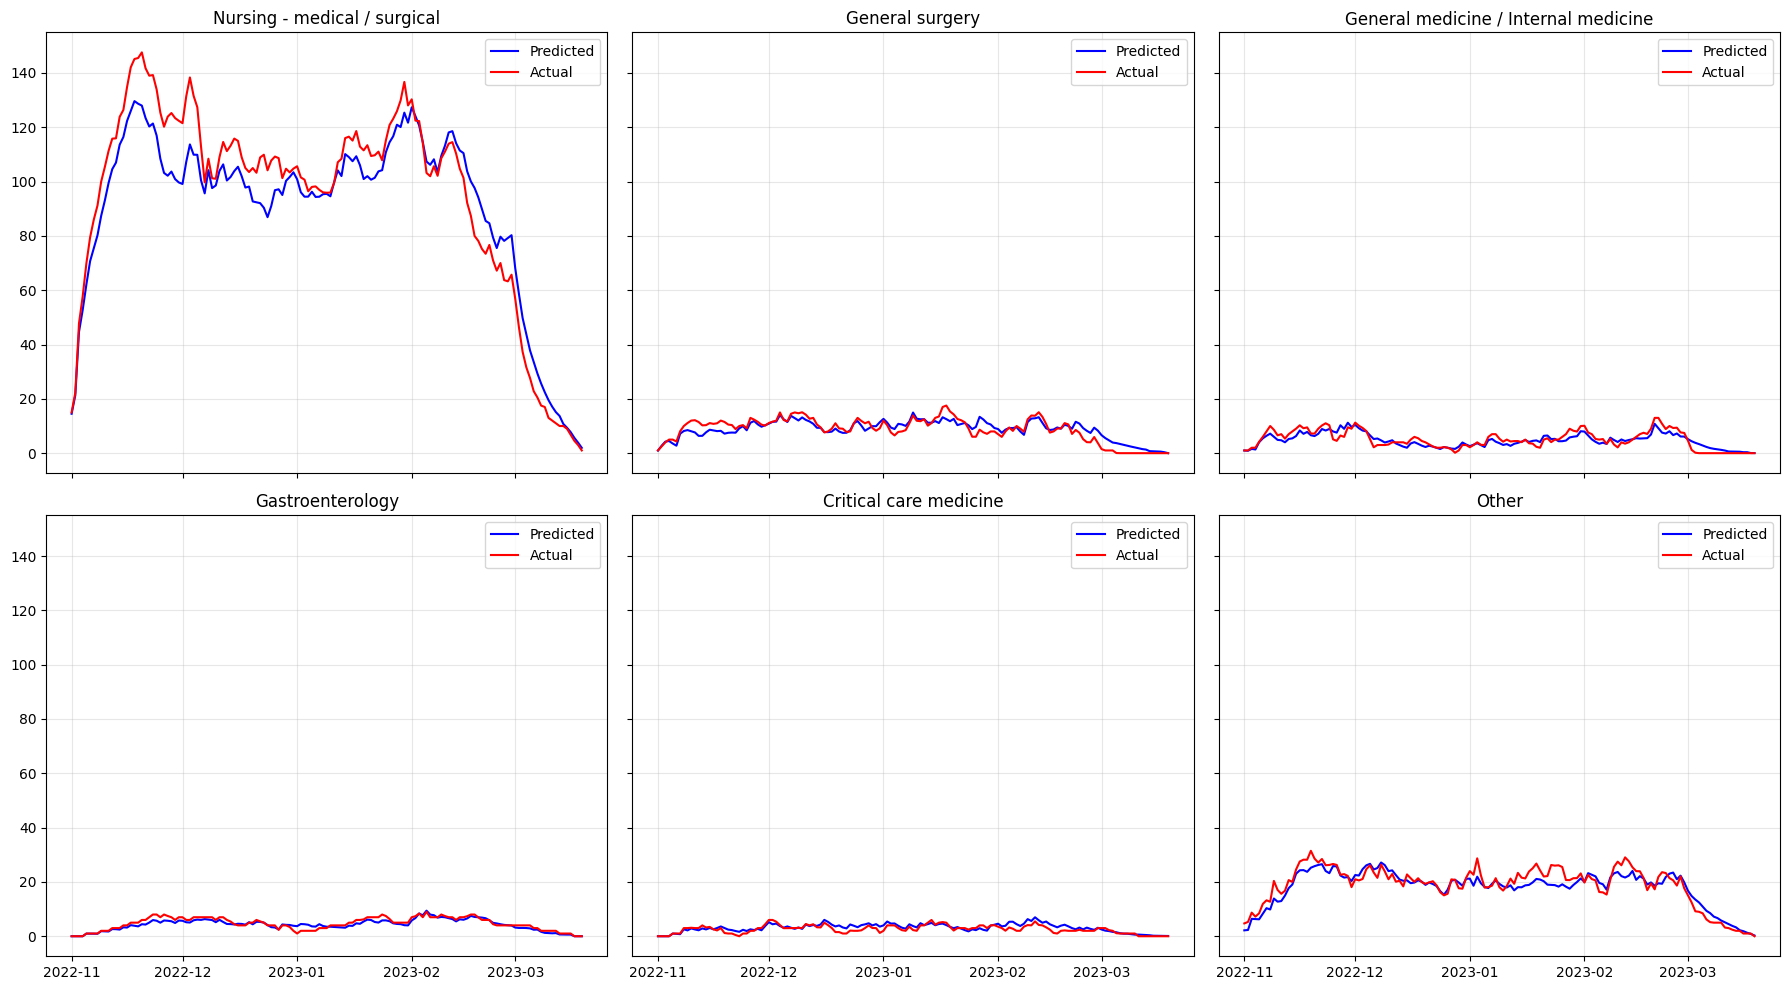

In [50]:
services = predicted_pivot_modified.columns

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10), sharex=True, sharey=True)

for i, service in enumerate(services):
    ax = axes.flat[i]
    ax.plot(predicted_pivot_modified.index, predicted_pivot_modified[service], label='Predicted', color='blue')
    ax.plot(actual_pivot_modified.index, actual_pivot_modified[service], label='Actual', color='red')
    ax.set_title(f'{service}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [55]:
df_test.encounter_medical_service.unique()

array(['Nursing - medical / surgical', 'Emergency medicine',
       'General surgery', 'Orthopedic surgery', 'Pediatrics',
       'Pulmonology', 'General medicine / Internal medicine', 'Neurology',
       'Cardiology', 'Critical care medicine', 'Gastroenterology',
       'Cardiovascular services', 'Psychiatry / Behavioral health',
       'Obstetrics / Gynecology / Midwifery', 'Hematology / Oncology',
       'Physical medicine and Rehab', 'Cath lab',
       'Hospice and palliative medicine', 'Nephrology',
       'Pediatric hematology/oncology'], dtype=object)

In [51]:
out = (
    df_test.assign(
        los=lambda d: d["encounter_duration_days"].astype(float).clip(upper=los_to_predict),
        full_days=lambda d: np.floor(d["los"]).astype(int),
        rem=lambda d: d["los"] - np.floor(d["los"]),
    )
)

full_part = (
    out.loc[out["full_days"] > 0, ["encounter_start_dt", "full_days"]]
      .assign(day_offset=lambda d: d["full_days"].apply(lambda n: list(range(n))))
      .explode("day_offset")
      .assign(date=lambda d: d["encounter_start_dt"] + pd.to_timedelta(d["day_offset"].astype(int), unit="D"),
              contrib=1.0)[["date", "contrib"]]
)

rem_part = (
    out.loc[out["rem"] > 0, ["encounter_start_dt", "full_days", "rem"]]
      .assign(date=lambda d: d["encounter_start_dt"] + pd.to_timedelta(d["full_days"], unit="D"),
              contrib=lambda d: d["rem"])[["date", "contrib"]]
)

actual_daily_workload = (
    pd.concat([full_part, rem_part], ignore_index=True)
      .groupby("date", as_index=False)["contrib"].sum()
      .rename(columns={"contrib": "workload_bed_days"})
      .sort_values("date")
)

In [52]:
actual_daily_workload

,date,workload_bed_days
0,2022-11-01 00:00:00+00:00,21.722917
1,2022-11-02 00:00:00+00:00,31.017361
2,2022-11-03 00:00:00+00:00,62.497222
3,2022-11-04 00:00:00+00:00,71.990278
4,2022-11-05 00:00:00+00:00,89.536806
...,...,...
134,2023-03-15 00:00:00+00:00,12.000000
135,2023-03-16 00:00:00+00:00,8.789583
136,2023-03-17 00:00:00+00:00,5.530556
137,2023-03-18 00:00:00+00:00,4.000000


In [53]:
df_test.encounter_start_dt.sort_values()

1596   2022-11-01 00:00:00+00:00
848    2022-11-01 00:00:00+00:00
601    2022-11-01 00:00:00+00:00
2720   2022-11-01 00:00:00+00:00
932    2022-11-01 00:00:00+00:00
                  ...           
1199   2023-02-28 00:00:00+00:00
447    2023-02-28 00:00:00+00:00
1442   2023-02-28 00:00:00+00:00
308    2023-02-28 00:00:00+00:00
302    2023-02-28 00:00:00+00:00
Name: encounter_start_dt, Length: 3024, dtype: datetime64[ns, UTC]

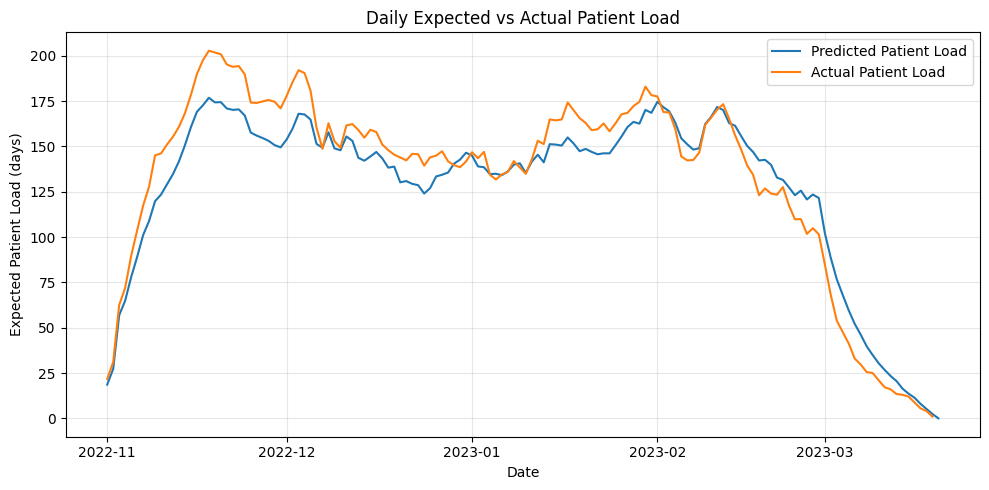

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(daily_workload_df["date"],
         daily_workload_df["expected_workload"],
         label="Predicted Patient Load")

plt.plot(actual_daily_workload["date"],
         actual_daily_workload["workload_bed_days"],
         label="Actual Patient Load")

plt.xlabel("Date")
plt.ylabel("Expected Patient Load (days)")
plt.title("Daily Expected vs Actual Patient Load")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
